In [33]:
import numpy as np
import pandas as pd
import seaborn as sns

from helper import convert_to_usd

# scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, QuantileTransformer

read data from /data using pandas

In [34]:
complexity_weight_df = pd.read_csv(
    "../data/cleaned/Cleaned Extracted Job Descriptions.csv",
    index_col=0
)

In [35]:
complexity_weight_df.head()

,TITLE,UID,SKILL CATEGORY,SKILL,COMPLEXITY,WEIGHT,COMPLEXITY x WEIGHT
ID,,,,,,,
4,Project Title: Build API access to acquired fl...,4-T1,TECH,Build API access to acquired flood data,4,40,160
4,NaN,4-T3,TECH,Design the API,5,70,350
4,NaN,4-T4,TECH,Optimize the API for efficient data retrieval ...,5,70,350
4,NaN,4-T5,TECH,building APIs,4,40,160
4,NaN,4-T6,TECH,data analysis,4,70,280


In [36]:

salary_df = pd.read_csv("../data/raw/Validators' Skill Sheet - Complexity Score.csv")
salary_df = salary_df.set_index(["ID"])

In [37]:
complexity_weight_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2425 entries, 4 to 8162
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   TITLE                140 non-null    object
 1   UID                  2425 non-null   object
 2   SKILL CATEGORY       2425 non-null   object
 3   SKILL                2425 non-null   object
 4   COMPLEXITY           2425 non-null   int64 
 5   WEIGHT               2425 non-null   int64 
 6   COMPLEXITY x WEIGHT  2425 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 151.6+ KB


In [38]:
freelancer_df = pd.read_csv('../data/raw/Freelancer Data.csv')
# set index to 1
freelancer_df.index = freelancer_df.index + 1

In [39]:
freelancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5707 entries, 1 to 5707
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_title              5707 non-null   object 
 1   Industry               6 non-null      object 
 2   Keywords               6 non-null      object 
 3   Assigned Industry      5707 non-null   object 
 4   projectId              5707 non-null   int64  
 5   job_description        5707 non-null   object 
 6   tags                   5707 non-null   object 
 7   client_state           5486 non-null   object 
 8   client_country         5707 non-null   object 
 9   client_average_rating  5707 non-null   float64
 10  client_review_count    5707 non-null   int64  
 11  min_price              5707 non-null   int64  
 12  max_price              5707 non-null   int64  
 13  avg_price              5707 non-null   float64
 14  currency               5707 non-null   object 
 15  rate

In [40]:
freelancer_df.head()

,job_title,Industry,Keywords,Assigned Industry,projectId,job_description,tags,client_state,client_country,client_average_rating,client_review_count,min_price,max_price,avg_price,currency,rate_type
1,development and implementation of a federated ...,Data Science,"data, analytics, python, regression, excel, sp...",AI / ML,37426471,please bid only if you are ready to do the wor...,"['algorithm', 'java', 'python', 'machine learn...",Heilbronn,Germany,5.0,17,8,30,19.0,EUR,fixed
2,Data Scrap,Cybersecurity,"security, SOC, cybersecurity, IoT",Data Science,37400492,I am looking for a freelancer who can help me ...,"['web scraping', 'data mining', 'data entry', ...",Eaubonne,France,5.0,1,30,250,140.0,EUR,fixed
3,Big Data Project,Database / BI,"database, Power BI, SQL, BI, business intellig...",Data Science,37404568,Store Sales Data Analysis: A Data Engineering ...,"['big data sales', 'data science', 'data minin...",Mundra,India,5.0,2,5000,5500,5250.0,INR,fixed
4,Build API access to data,Data Analyst,"data, analytics, analyst, BI, business intelli...",Data Science,37390097,Project Title: Build API access to acquired fl...,"['python', 'php', 'javascript', 'software arch...",Crewe,United Kingdom,5.0,1,250,750,500.0,USD,fixed
5,Develop an AI website from the ground up,Coders/Programmers,"code, coding, program, python, programmer, pro...",AI / ML,37432305,I am looking for a skilled developer to create...,"['java', 'website design', 'html', 'python', '...",Rishon LeTsiyyon,Israel,0.0,0,5000,10000,7500.0,USD,fixed


## Preprocessing

In [41]:
salary_ranges_df = freelancer_df[['min_price', 'max_price', 'job_title']].copy()
merged_salaries_df = salary_ranges_df.merge(salary_df, left_index=True, right_index=True)
merged_salaries_df.head()

,min_price,max_price,job_title,Job Title,Job Description,Sum of Weights,Sum of (Complexity x Weight),Complexity Score,Amount,Currency,Country,Country Category
4,250,750,Build API access to data,Build API access to data,Project Title: Build API access to acquired fl...,840,3710,4.416667,500,USD,United Kingdom,High income
100,30,250,R studio data analysis ranking variables on ho...,Multimodal Neural Network for Financial Data A...,Project Overview: I am looking to develop a cu...,1550,6970,4.496774,500,USD,United Arab Emirates,High income
163,10,20,coding using Rstudio,Reconciliation of GST Invoices between two Sou...,I am looking for a skilled developer who can h...,670,2570,3.835821,7000,INR,India,Lower middle income
194,30,250,Drawing PowerBI dashboard from SQL Server,Need complex sample tableau dashboards (financ...,Project Description: Complex Sample Tableau Da...,1030,4410,4.281553,140,USD,United States,High income
256,8,30,BUS385 Business Analytics for Decision Making ...,App Statistics Module Developer Needed,Project Overview: Seeking an experienced app d...,910,3970,4.362637,500,USD,Denmark,High income


In [42]:
merged_salaries_df.size

1128

In [43]:
merged_salaries_df["Amount"] = merged_salaries_df.apply(convert_to_usd, axis=1, args=["Amount"])

In [44]:
merged_salaries_df.head()

,min_price,max_price,job_title,Job Title,Job Description,Sum of Weights,Sum of (Complexity x Weight),Complexity Score,Amount,Currency,Country,Country Category
4,250,750,Build API access to data,Build API access to data,Project Title: Build API access to acquired fl...,840,3710,4.416667,500.000000,USD,United Kingdom,High income
100,30,250,R studio data analysis ranking variables on ho...,Multimodal Neural Network for Financial Data A...,Project Overview: I am looking to develop a cu...,1550,6970,4.496774,500.000000,USD,United Arab Emirates,High income
163,10,20,coding using Rstudio,Reconciliation of GST Invoices between two Sou...,I am looking for a skilled developer who can h...,670,2570,3.835821,81.628572,INR,India,Lower middle income
194,30,250,Drawing PowerBI dashboard from SQL Server,Need complex sample tableau dashboards (financ...,Project Description: Complex Sample Tableau Da...,1030,4410,4.281553,140.000000,USD,United States,High income
256,8,30,BUS385 Business Analytics for Decision Making ...,App Statistics Module Developer Needed,Project Overview: Seeking an experienced app d...,910,3970,4.362637,500.000000,USD,Denmark,High income


In [45]:
filtered_salary_df = salary_df[[    
    "Complexity Score",
    "Amount",
    "Country",
    "Country Category"
]].copy()

In [46]:
filtered_salary_df.head()

,Complexity Score,Amount,Country,Country Category
ID,,,,
4,4.416667,500,United Kingdom,High income
100,4.496774,500,United Arab Emirates,High income
163,3.835821,7000,India,Lower middle income
194,4.281553,140,United States,High income
256,4.362637,500,Denmark,High income


In [47]:
filtered_complexity_weight_df = complexity_weight_df[[    
    "COMPLEXITY",
    "WEIGHT",
    "SKILL CATEGORY"
]].copy()

In [48]:
filtered_complexity_weight_df['SKILL CATEGORY'].unique()

array(['TECH', 'SOFT SKILL', 'OTHERS'], dtype=object)

In [49]:
filtered_complexity_weight_df.head()

,COMPLEXITY,WEIGHT,SKILL CATEGORY
ID,,,
4,4,40,TECH
4,5,70,TECH
4,5,70,TECH
4,4,40,TECH
4,4,70,TECH


In [50]:
weight_columns = [col for col in filtered_complexity_weight_df.columns if "WEIGHT" in col.upper()]
for col in weight_columns:
    filtered_complexity_weight_df[col] = pd.to_numeric(filtered_complexity_weight_df[col], errors="coerce")
    if filtered_complexity_weight_df[col].max(skipna=True) > 1:
        filtered_complexity_weight_df[col] = filtered_complexity_weight_df[col] / 100
filtered_complexity_weight_df.head()

,COMPLEXITY,WEIGHT,SKILL CATEGORY
ID,,,
4,4,0.4,TECH
4,5,0.7,TECH
4,5,0.7,TECH
4,4,0.4,TECH
4,4,0.7,TECH


generate RMS and top-k scores based off complexity scores

In [51]:
TOP_K = 3


def _rms_score(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return pd.NA
    return float(np.sqrt(np.mean(np.square(values))))


def _top_k_score(series, k=TOP_K):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return pd.NA
    return float(values.nlargest(min(k, len(values))).mean())


# Power-transform the weights before computing the weighted mean, while keeping
# the RMS and top-k complexity summaries based on the raw complexity values.
weight_transformer = PowerTransformer(method="yeo-johnson")
filtered_complexity_weight_df["WEIGHT_POWER"] = weight_transformer.fit_transform(
    filtered_complexity_weight_df[["WEIGHT"]]
).ravel()

# Reconcile complexity and weight using weighted aggregates per index (ID).
sums_df = (
    filtered_complexity_weight_df
    .assign(
        COMPLEXITY_WEIGHT=lambda df: df["COMPLEXITY"] * df["WEIGHT"],
        COMPLEXITY_WEIGHT_POWER=lambda df: df["COMPLEXITY"] * df["WEIGHT_POWER"],
    )
    .groupby(level=0)
    .agg(
        COMPLEXITY_WEIGHT_SUM=("COMPLEXITY_WEIGHT", "sum"),
        COMPLEXITY_WEIGHT_POWER_SUM=("COMPLEXITY_WEIGHT_POWER", "sum"),
        COMPLEXITY_SUM=("COMPLEXITY", "sum"),
        WEIGHT_SUM=("WEIGHT", "sum"),
        WEIGHT_POWER_SUM=("WEIGHT_POWER", "sum"),
        ROW_COUNT=("COMPLEXITY_WEIGHT", "size"),
        COMPLEXITY_RMS=("COMPLEXITY", _rms_score),
        TOP_K_COMPLEXITY_SCORE=("COMPLEXITY", _top_k_score),
    )
)

# Use the power-transformed weights for the weighted mean only.
sums_df["COMPLEXITY_WEIGHT_MEAN"] = (
    sums_df["COMPLEXITY_WEIGHT_POWER_SUM"] / sums_df["WEIGHT_POWER_SUM"].replace(0, pd.NA)
)

sums_df.head()

,COMPLEXITY_WEIGHT_SUM,COMPLEXITY_WEIGHT_POWER_SUM,COMPLEXITY_SUM,WEIGHT_SUM,WEIGHT_POWER_SUM,ROW_COUNT,COMPLEXITY_RMS,TOP_K_COMPLEXITY_SCORE,COMPLEXITY_WEIGHT_MEAN
ID,,,,,,,,,
4,37.1,-15.923677,57,8.4,-4.173782,13,4.428926,5.000000,3.815167
100,69.7,-69.661956,111,15.5,-17.839787,25,4.467662,5.000000,3.904865
163,25.7,-2.112039,38,6.7,-1.432000,10,3.872983,4.666667,1.474888
194,44.1,4.515865,64,10.3,0.647631,15,4.320494,5.000000,6.972897
256,39.7,2.401189,60,9.1,-1.015694,14,4.375255,5.000000,-2.364086


generate three columns for the ratio of tech skills, soft skills, other compared to total number of skills ('ROW_COUNT')

In [52]:
sums_df['ratio_tech_skill'] = filtered_complexity_weight_df['SKILL CATEGORY'].str.contains('tech', case=False, na=False).groupby(level=0).sum() / sums_df['ROW_COUNT']
sums_df['ratio_soft_skill'] = filtered_complexity_weight_df['SKILL CATEGORY'].str.contains('soft', case=False, na=False).groupby(level=0).sum() / sums_df['ROW_COUNT']
sums_df['ratio_other_skill'] = filtered_complexity_weight_df['SKILL CATEGORY'].str.contains('other', case=False, na=False).groupby(level=0).sum() / sums_df['ROW_COUNT']

In [53]:
sums_df.head()

,COMPLEXITY_WEIGHT_SUM,COMPLEXITY_WEIGHT_POWER_SUM,COMPLEXITY_SUM,WEIGHT_SUM,WEIGHT_POWER_SUM,ROW_COUNT,COMPLEXITY_RMS,TOP_K_COMPLEXITY_SCORE,COMPLEXITY_WEIGHT_MEAN,ratio_tech_skill,ratio_soft_skill,ratio_other_skill
ID,,,,,,,,,,,,
4,37.1,-15.923677,57,8.4,-4.173782,13,4.428926,5.000000,3.815167,0.769231,0.076923,0.153846
100,69.7,-69.661956,111,15.5,-17.839787,25,4.467662,5.000000,3.904865,0.640000,0.000000,0.360000
163,25.7,-2.112039,38,6.7,-1.432000,10,3.872983,4.666667,1.474888,0.500000,0.200000,0.300000
194,44.1,4.515865,64,10.3,0.647631,15,4.320494,5.000000,6.972897,0.733333,0.066667,0.200000
256,39.7,2.401189,60,9.1,-1.015694,14,4.375255,5.000000,-2.364086,0.785714,0.000000,0.214286


In [54]:
left_df = filtered_salary_df.reset_index()
right_df = sums_df.reset_index()

overlap_cols = [col for col in right_df.columns if col in left_df.columns and col != "ID"]
right_df = right_df.drop(columns=overlap_cols)

merged_dataset_raw = (
    left_df
    .merge(right_df, on="ID", how="inner")
    .set_index("ID")
)


In [55]:
merged_dataset_raw.head(10)

,Complexity Score,Amount,Country,Country Category,COMPLEXITY_WEIGHT_SUM,COMPLEXITY_WEIGHT_POWER_SUM,COMPLEXITY_SUM,WEIGHT_SUM,WEIGHT_POWER_SUM,ROW_COUNT,COMPLEXITY_RMS,TOP_K_COMPLEXITY_SCORE,COMPLEXITY_WEIGHT_MEAN,ratio_tech_skill,ratio_soft_skill,ratio_other_skill
ID,,,,,,,,,,,,,,,,
4,4.416667,500,United Kingdom,High income,37.1,-15.923677,57,8.4,-4.173782,13,4.428926,5.000000,3.815167,0.769231,0.076923,0.153846
100,4.496774,500,United Arab Emirates,High income,69.7,-69.661956,111,15.5,-17.839787,25,4.467662,5.000000,3.904865,0.640000,0.000000,0.360000
163,3.835821,7000,India,Lower middle income,25.7,-2.112039,38,6.7,-1.432000,10,3.872983,4.666667,1.474888,0.500000,0.200000,0.300000
194,4.281553,140,United States,High income,44.1,4.515865,64,10.3,0.647631,15,4.320494,5.000000,6.972897,0.733333,0.066667,0.200000
256,4.362637,500,Denmark,High income,39.7,2.401189,60,9.1,-1.015694,14,4.375255,5.000000,-2.364086,0.785714,0.000000,0.214286
302,4.735849,140,Sri Lanka,Lower middle income,50.2,22.243695,71,10.6,4.572171,15,4.767949,5.000000,4.865018,0.933333,0.000000,0.066667
352,3.953488,20,United States,High income,34.0,-9.903703,51,8.6,-3.046275,13,4.028743,5.000000,3.251086,0.538462,0.230769,0.230769
411,4.813953,2750,France,High income,62.1,-6.890476,91,12.9,-2.301207,19,4.806793,5.000000,2.994288,0.789474,0.000000,0.210526
467,4.773810,500,Portugal,High income,40.1,16.159093,57,8.4,2.801121,12,4.787136,5.000000,5.768796,0.916667,0.000000,0.083333


/var/folders/jd/rmzvvh4s2jzg55h334m9_q040000gn/T/ipykernel_87805/3955498642.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(


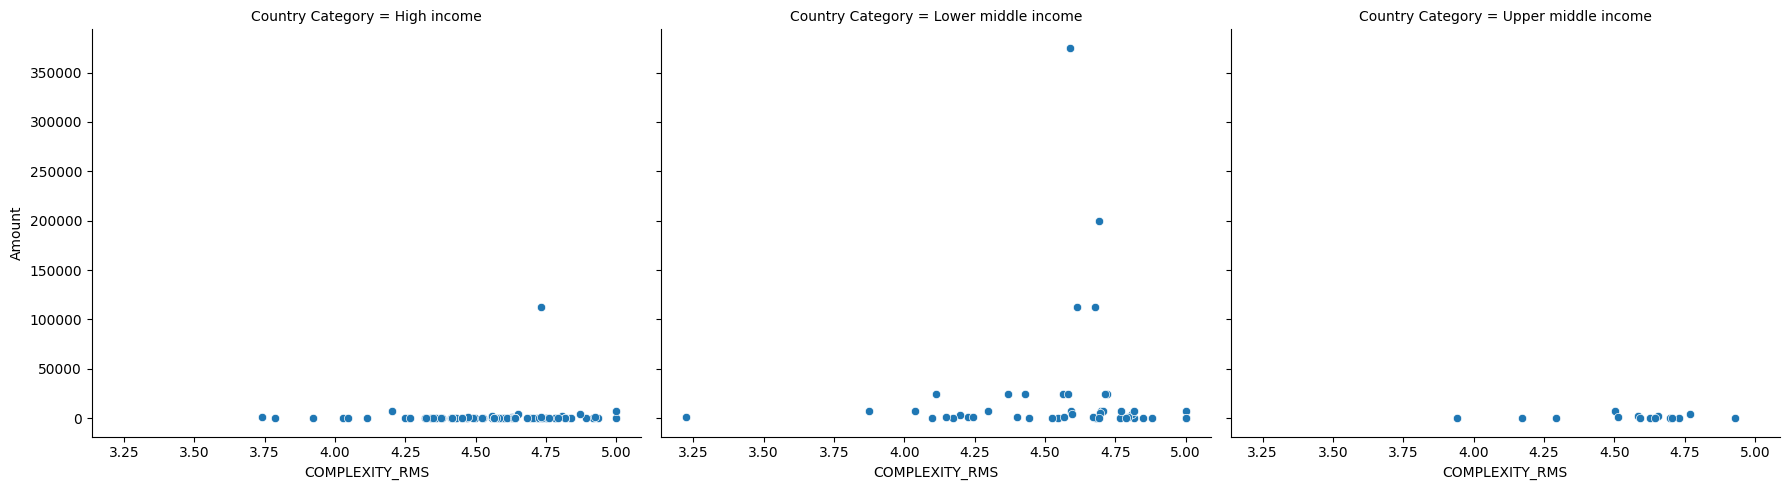

In [56]:
sns.relplot(
    data=merged_dataset_raw,
    x="COMPLEXITY_RMS",
    y="Amount",
    col="Country Category",
    height=5,
    aspect=1.2,
    palette="Set2"
)

/var/folders/jd/rmzvvh4s2jzg55h334m9_q040000gn/T/ipykernel_87805/1092590034.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(


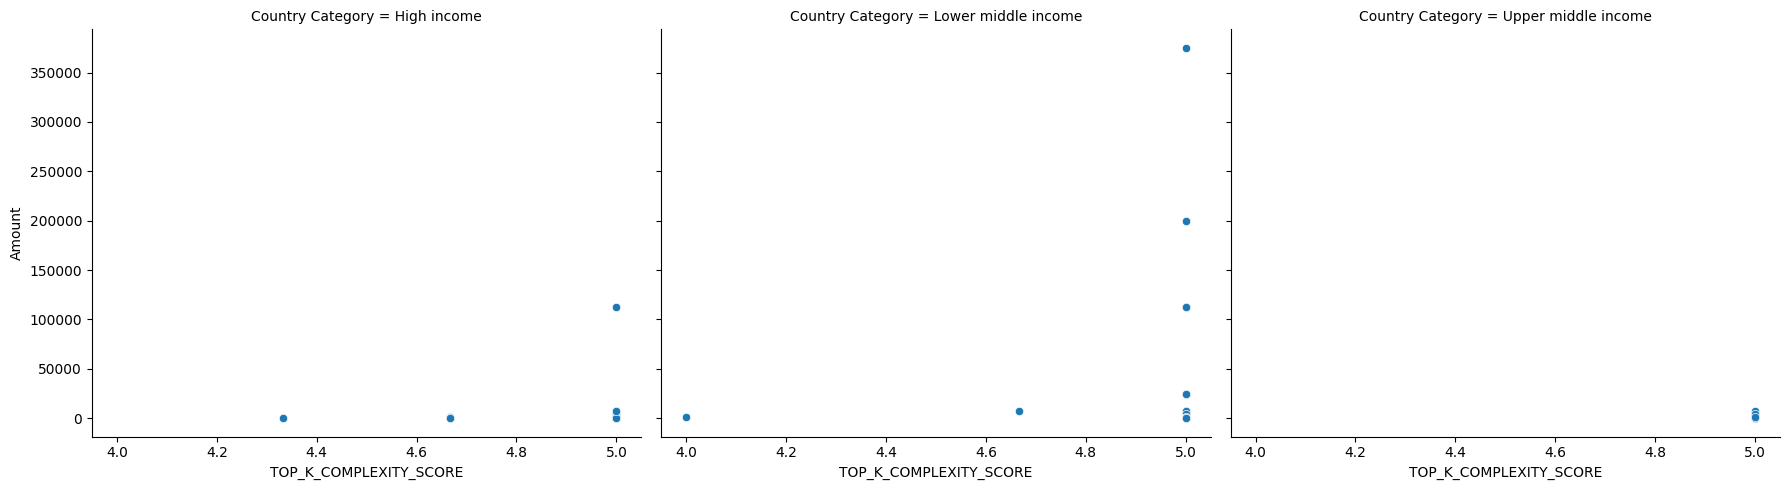

In [57]:
sns.relplot(
    data=merged_dataset_raw,
    x="TOP_K_COMPLEXITY_SCORE",
    y="Amount",
    col="Country Category",
    height=5,
    aspect=1.2,
    palette="Set2"
)

/var/folders/jd/rmzvvh4s2jzg55h334m9_q040000gn/T/ipykernel_87805/1212848938.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(


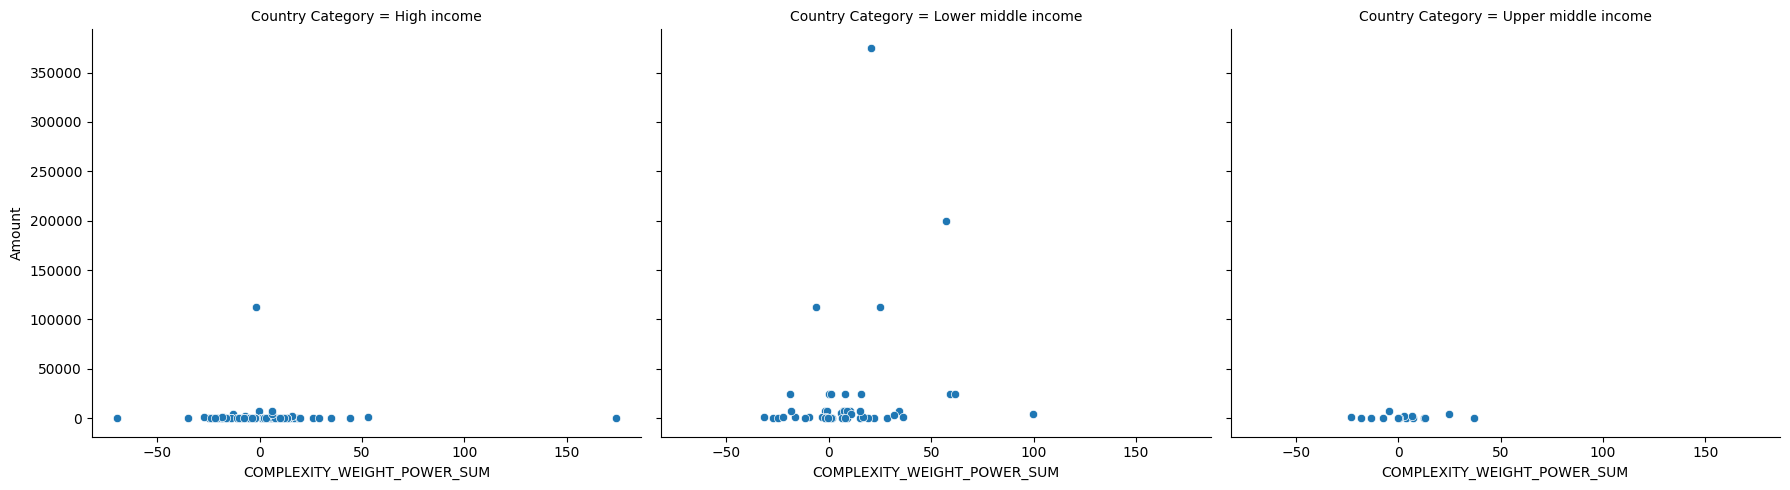

In [58]:
sns.relplot(
    data=merged_dataset_raw,
    x="COMPLEXITY_WEIGHT_POWER_SUM",
    y="Amount",
    col="Country Category",
    height=5,
    aspect=1.2,
    palette="Set2"
)

In [111]:
signals = [
    "Amount",
    "Country",
    "Country Category",
    "COMPLEXITY_RMS",
    "TOP_K_COMPLEXITY_SCORE",
    "COMPLEXITY_WEIGHT_MEAN",
    "COMPLEXITY_WEIGHT_SUM",
    "COMPLEXITY_WEIGHT_POWER_SUM",
    "COMPLEXITY_SUM",
    "WEIGHT_SUM",
    "ROW_COUNT",
    "ratio_tech_skill",
    "ratio_other_skill",
    "ratio_soft_skill",
]

data = merged_dataset_raw[signals].copy()

## Modelling

In [112]:
# Remove salary outliers using z-score threshold of 3.
amount_mean = data["Amount"].mean()
amount_std = data["Amount"].std(ddof=0)

if amount_std != 0:
    amount_z_scores = (data["Amount"] - amount_mean) / amount_std
    data = data[amount_z_scores.abs() <= 3].copy()

In [113]:
# Predict amount from RMS and top-k complexity features + location features.
X = data[[
    # "COMPLEXITY_RMS",
    "TOP_K_COMPLEXITY_SCORE",
    # "COMPLEXITY_WEIGHT_POWER_SUM",
    # "Country",
    "Country Category",
    "ratio_tech_skill",
    "ratio_other_skill",
    "ratio_soft_skill",
]]
y = data["Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Regression
---

In [114]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01), ["Country Category"]),
        ("numerical", QuantileTransformer(n_quantiles=100, output_distribution="uniform", random_state=42), ["TOP_K_COMPLEXITY_SCORE"]),
    ],
    remainder="passthrough",
    sparse_threshold=0,
    verbose_feature_names_out=False,
)

In [115]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [116]:
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate R² and RMSE on the raw amount scale.
r2_raw = r2_score(y_test, y_pred)
rmse_raw = root_mean_squared_error(y_test, y_pred)
mae_raw = mean_absolute_error(y_test, y_pred)
mse_raw = mean_squared_error(y_test, y_pred)

# 1. Adjusted R² (raw scale)
n_test = len(y_test)
p = X_test.shape[1]
adjusted_r2_raw = 1 - (1 - r2_raw) * (n_test - 1) / (n_test - p - 1)

# 2. Error metrics on the raw amount scale
# No log transform is applied, so the predictions are already in original units.

# 3. P-value for overall model (raw scale)
# Get predictions on full training set to calculate F-statistic and p-value
y_pred_train = model.predict(X_train)
ss_res = np.sum((y_train - y_pred_train) ** 2)  # Residual sum of squares
ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)  # Total sum of squares
mean_sq_res = ss_res / (len(y_train) - p - 1)
mean_sq_tot = ss_tot / (p - 1)
f_statistic = mean_sq_tot / mean_sq_res
p_value = 1 - stats.f.cdf(f_statistic, p - 1, len(y_train) - p - 1)

# Display all results
print("=== Extended Regression Metrics ===\n")
print("Raw-Scale Metrics (Model's prediction space):")
print(f"  R²: {r2_raw:.4f}")
print(f"  Adjusted R²: {adjusted_r2_raw:.4f}")
print(f"  MAE: {mae_raw:.4f}")
print(f"  MSE: {mse_raw:.4f}")
print(f"  RMSE: {rmse_raw:.4f}\n")

print("Model Significance:")
print(f"  F-statistic: {f_statistic:.4f}")
print(f"  P-value: {p_value:.4e}")


=== Extended Regression Metrics ===

Raw-Scale Metrics (Model's prediction space):
  R²: 0.0785
  Adjusted R²: -0.1309
  MAE: 7560.3627
  MSE: 410777399.9393
  RMSE: 20267.6442

Model Significance:
  F-statistic: 27.5892
  P-value: 1.3323e-15


# Conclusion